# AUP — SECAP Charts

Produces all charts defined in `data/CHARTS_DEFINITIONS.md`.  
Charts are saved to `{SCENARIO_DIR}/outputs/charts/`.

**Scope: built environment (buildings) only.**  
**Run the kernel from the AUP_Gui- `.venv`** (has pandas, geopandas, matplotlib, seaborn).

| # | Chart | SECAP Section |
|---|-------|---------------|
| KPI | District summary banner | §3 BEI |
| 1 | Energy mix + CO₂ secondary axis | §3 BEI |
| A | End-use breakdown donut | §3 BEI |
| B | Emissions vs 2030 target gauge | §2.2 Commitments |
| C | Building sector mix (residential / tertiary) | §3 BEI by sector |
| 2 | Load duration curves | §5 Mitigation — infrastructure sizing |
| 3 | Monthly demand profile | §4 RVA seasonal |
| 4 | Heat stress risk heatmap | §4 RVA heatwave + §6 Adaptation |
| 5 | EUI distribution + outlier flags | §3 BEI + §5 targeting |
| 6 | Solar PV potential vs demand | §5 Mitigation — solar |
| 7 | District energy loop opportunity | §5 Mitigation — heat exchange |
| 8 | CO₂ reduction waterfall | §5 Mitigation — GHG reduction per action |
| D | Fossil phase-out timeline | §5 Mitigation — timing + §2.7 monitoring |


In [33]:
# Install missing packages (run once if needed)
import subprocess, sys
for pkg in ['matplotlib', 'seaborn']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
print('packages ready')

packages ready


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import os
import glob
from pathlib import Path

# ── CONFIGURE THESE PATHS ───────────────────────────────────────────────────
SCENARIO_DIR = "/home/salva/iaac/Automatic-urban-planner/output-scenario-20260308_211038"
TYPOLOGY_DBF = "/home/salva/iaac/Automatic-urban-planner/munich-scenario/inputs/building-properties/typology.dbf"
# ────────────────────────────────────────────────────────────────────────────

DEMAND_DIR    = f"{SCENARIO_DIR}/outputs/data/demand"
RADIATION_DIR = f"{SCENARIO_DIR}/outputs/data/solar-radiation"

# Emission factors [tCO2/MWh] — configurable
EF = {
    'NG':   0.202,   # natural gas   (IPCC AR6)
    'COAL': 0.341,   # hard coal     (IPCC AR6)
    'OIL':  0.266,   # fuel oil      (IPCC AR6)
    'WOOD': 0.017,   # wood/biomass  (IPCC AR6 biogenic)
    'DH':   0.070,   # district heat (AGFW DE 2022)
    'GRID': 0.366,   # DE grid 2023  (UBA 2024)
    'SOLAR': 0.000,
    'PV':   0.000,
}

PALETTE = {
    'Grid':           '#4472C4',
    'Natural Gas':    '#FF7043',
    'District Heat':  '#42A5F5',
    'Solar Thermal':  '#FDD835',
    'Oil':            '#8D6E63',
    'Coal':           '#616161',
    'Wood/Biomass':   '#66BB6A',
    'Space Heating':  '#EF5350',
    'DHW':            '#FF8A65',
    'Cooling':        '#29B6F6',
    'Appliances':     '#AB47BC',
    'Lighting':       '#FFEE58',
}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

CHARTS_OUT = f"{SCENARIO_DIR}/outputs/charts"
os.makedirs(CHARTS_OUT, exist_ok=True)
print(f"Scenario  : {SCENARIO_DIR}")
print(f"Charts out: {CHARTS_OUT}")

Scenario  : /home/salva/iaac/Automatic-urban-planner/output-scenario-20260308_211038
Charts out: /home/salva/iaac/Automatic-urban-planner/output-scenario-20260308_211038/outputs/charts


In [35]:
# ── Load Data ───────────────────────────────────────────────────────────────

# Annual per-building demand
df = pd.read_csv(f"{DEMAND_DIR}/Total_demand.csv").set_index('name')

# Hourly district-total demand
dfh = pd.read_csv(f"{DEMAND_DIR}/Total_demand_hourly.csv", parse_dates=['date']).set_index('date')

# Typology (building use type + year)
try:
    typo_path = f"{SCENARIO_DIR}/inputs/building-properties/typology.dbf"
    if not Path(typo_path).exists():
        typo_path = TYPOLOGY_DBF
    typo = (
        gpd.read_file(typo_path)[['Name', '1ST_USE', 'YEAR', 'STANDARD']]
        .rename(columns={'Name': 'name'})
        .set_index('name')
    )
    df = df.join(typo, how='left')
    print("Typology joined ✓")
except Exception as e:
    print(f"Typology not available ({e}) — sector chart will be skipped")
    df['1ST_USE'] = pd.NA
    df['YEAR'] = pd.NA

# Solar radiation — total annual roof irradiation per building (MWh)
rad_data = {}
for fp in sorted(glob.glob(f"{RADIATION_DIR}/*_radiation.csv")):
    bname = Path(fp).stem.replace('_radiation', '')
    r = pd.read_csv(fp, parse_dates=['Date'])
    rad_data[bname] = r['roofs_top_kW'].sum() / 1e3  # MWh
df['solar_roof_MWh'] = pd.Series(rad_data)

print(f"Buildings loaded : {len(df)}")
print(f"Hourly rows      : {len(dfh):,}  (should be 8,760)")
print(f"Radiation files  : {len(rad_data)}")
df[['GFA_m2', 'Aroof_m2', 'QH_sys_MWhyr', 'QC_sys_MWhyr', 'GRID_MWhyr', 'solar_roof_MWh']].round(1)

Typology joined ✓
Buildings loaded : 6
Hourly rows      : 8,760  (should be 8,760)
Radiation files  : 6


,GFA_m2,Aroof_m2,QH_sys_MWhyr,QC_sys_MWhyr,GRID_MWhyr,solar_roof_MWh
name,,,,,,
B1000,2203.9,1101.9,71.7,0.0,84.8,1230.8
B1001,6.4,1.6,0.7,0.0,0.2,1.7
B1002,28450.9,3537.7,808.9,0.0,1094.4,4190.2
B1003,27081.7,3857.8,785.0,0.0,1041.8,4568.7
B1004,21660.2,2714.4,634.7,0.0,833.5,3214.7
B1005,20093.0,2499.7,597.7,0.0,773.0,2961.5


In [36]:
# ── KPI Banner ──────────────────────────────────────────────────────────────

total_heat = df['QH_sys_MWhyr'].sum()
total_cool = df['QC_sys_MWhyr'].sum()
total_grid = df['GRID_MWhyr'].sum()
total_gfa  = df['GFA_m2'].sum()

total_co2 = (
    total_grid * EF['GRID']
    + (df['NG_hs_MWhyr']   + df['NG_ww_MWhyr']).sum()   * EF['NG']
    + (df['COAL_hs_MWhyr'] + df['COAL_ww_MWhyr']).sum() * EF['COAL']
    + (df['OIL_hs_MWhyr']  + df['OIL_ww_MWhyr']).sum()  * EF['OIL']
    + (df['WOOD_hs_MWhyr'] + df['WOOD_ww_MWhyr']).sum() * EF['WOOD']
    + (df['DH_hs_MWhyr']   + df['DH_ww_MWhyr']).sum()   * EF['DH']
)

fossil_mwh = (
    df[['NG_hs_MWhyr', 'NG_ww_MWhyr',
        'COAL_hs_MWhyr', 'COAL_ww_MWhyr',
        'OIL_hs_MWhyr', 'OIL_ww_MWhyr']].sum(axis=1).sum()
)
total_final = (
    total_grid
    + df[['NG_hs_MWhyr', 'NG_ww_MWhyr', 'COAL_hs_MWhyr', 'COAL_ww_MWhyr',
          'OIL_hs_MWhyr', 'OIL_ww_MWhyr', 'WOOD_hs_MWhyr', 'WOOD_ww_MWhyr',
          'DH_hs_MWhyr', 'DH_ww_MWhyr', 'SOLAR_hs_MWhyr', 'SOLAR_ww_MWhyr']]
         .sum(axis=1).sum()
)
fossil_pct = fossil_mwh / total_final * 100 if total_final > 0 else 0.0

print(f"{'='*56}")
print(f"  DISTRICT KPIs — {len(df)} buildings / {total_gfa:,.0f} m² GFA")
print(f"{'='*56}")
print(f"  Total Heating Demand  : {total_heat:>10,.1f}  MWh/yr")
print(f"  Total Cooling Demand  : {total_cool:>10,.1f}  MWh/yr")
print(f"  Grid Electricity      : {total_grid:>10,.1f}  MWh/yr")
print(f"  District EUI (total)  : {total_final/total_gfa*1000:>10,.1f}  kWh/m²/yr")
print(f"  Total CO₂ Baseline    : {total_co2:>10,.1f}  tCO₂/yr")
print(f"  CO₂ Intensity         : {total_co2/total_gfa*1000:>10,.2f}  kgCO₂/m²/yr")
print(f"  Fossil Fuel Share     : {fossil_pct:>10,.1f}  %")
print(f"{'='*56}")

  DISTRICT KPIs — 6 buildings / 99,496 m² GFA
  Total Heating Demand  :    2,898.7  MWh/yr
  Total Cooling Demand  :        0.0  MWh/yr
  Grid Electricity      :    3,827.7  MWh/yr
  District EUI (total)  :       69.1  kWh/m²/yr
  Total CO₂ Baseline    :    2,017.3  tCO₂/yr
  CO₂ Intensity         :      20.28  kgCO₂/m²/yr
  Fossil Fuel Share     :       44.4  %


## Chart 1 — Energy Mix & CO₂ Baseline  *(§3 BEI)*

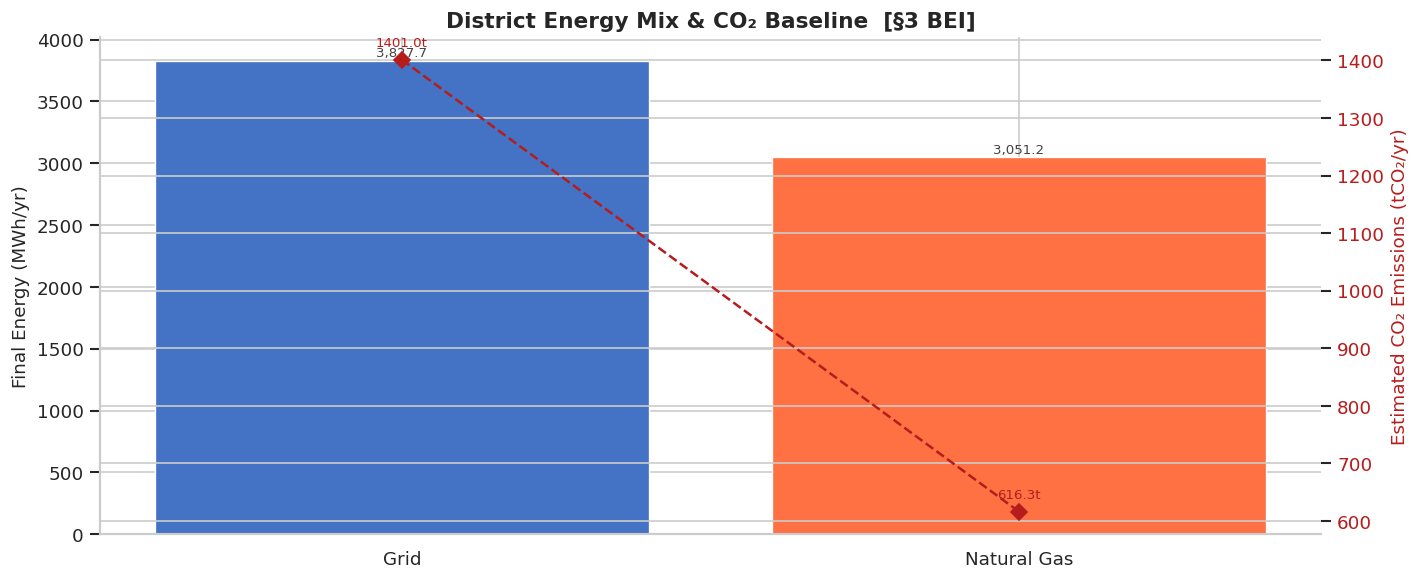

Total CO₂: 2,017.3 tCO₂/yr


In [37]:
carrier_energy = pd.Series({
    'Grid':           df['GRID_MWhyr'].sum(),
    'Natural Gas':   (df['NG_hs_MWhyr']   + df['NG_ww_MWhyr']).sum(),
    'District Heat': (df['DH_hs_MWhyr']   + df['DH_ww_MWhyr']).sum(),
    'Solar Thermal': (df['SOLAR_hs_MWhyr'] + df['SOLAR_ww_MWhyr']).sum(),
    'Oil':           (df['OIL_hs_MWhyr']  + df['OIL_ww_MWhyr']).sum(),
    'Coal':          (df['COAL_hs_MWhyr'] + df['COAL_ww_MWhyr']).sum(),
    'Wood/Biomass':  (df['WOOD_hs_MWhyr'] + df['WOOD_ww_MWhyr']).sum(),
})
carrier_energy = carrier_energy[carrier_energy > 0]

ef_map = {
    'Grid': EF['GRID'], 'Natural Gas': EF['NG'], 'District Heat': EF['DH'],
    'Solar Thermal': 0.0, 'Oil': EF['OIL'], 'Coal': EF['COAL'], 'Wood/Biomass': EF['WOOD'],
}
co2_vals = carrier_energy * pd.Series(ef_map).reindex(carrier_energy.index).fillna(0)
colors = [PALETTE.get(k, '#9E9E9E') for k in carrier_energy.index]

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(carrier_energy.index, carrier_energy.values, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_ylabel('Final Energy (MWh/yr)', fontsize=11)
ax1.set_title('District Energy Mix & CO₂ Baseline  [§3 BEI]', fontsize=13, fontweight='bold')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{bar.get_height():,.1f}', ha='center', fontsize=8, color='#424242')

ax2 = ax1.twinx()
ax2.plot(carrier_energy.index, co2_vals.values, 'D--',
         color='#B71C1C', markersize=7, linewidth=1.5, label='tCO₂/yr')
ax2.set_ylabel('Estimated CO₂ Emissions (tCO₂/yr)', fontsize=11, color='#B71C1C')
ax2.tick_params(axis='y', labelcolor='#B71C1C')
for i, (k, co2) in enumerate(co2_vals.items()):
    if co2 > 0:
        ax2.annotate(f'{co2:.1f}t',
                     xy=(i, co2), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=8, color='#B71C1C')

plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/01_energy_mix.png", bbox_inches='tight')
plt.show()
print(f"Total CO₂: {co2_vals.sum():,.1f} tCO₂/yr")

## Chart A — End-Use Breakdown  *(§3 BEI)*

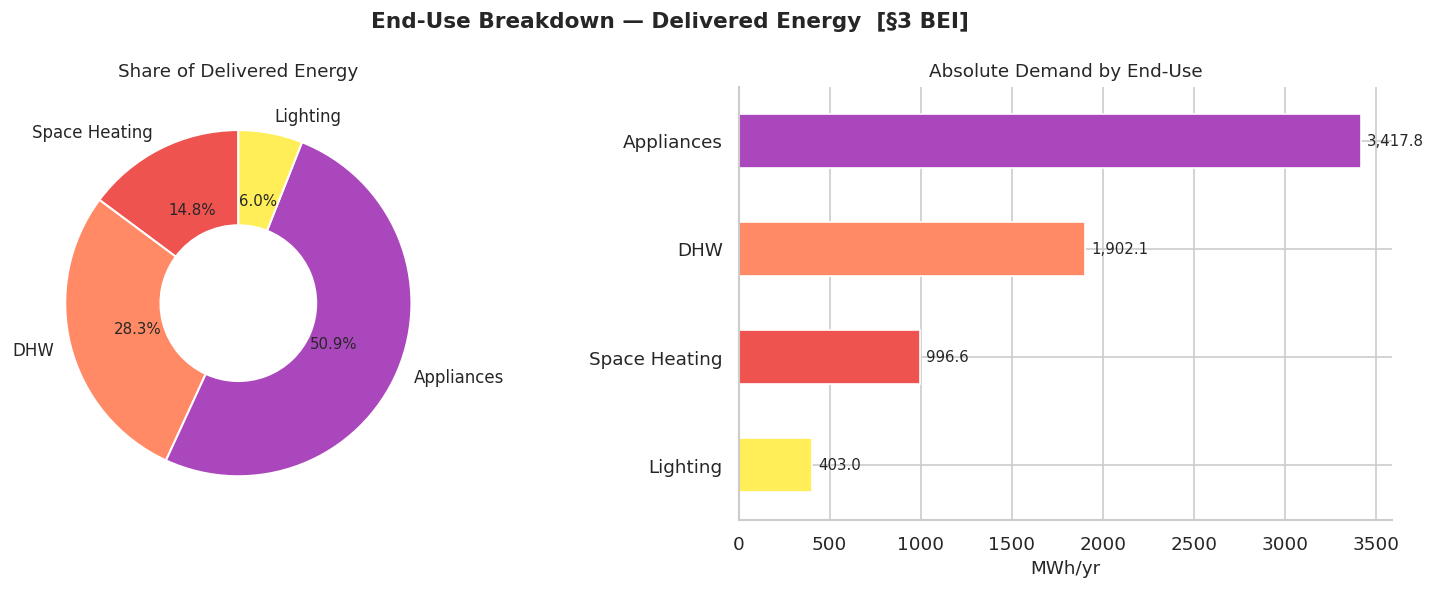

In [38]:
end_uses = pd.Series({
    'Space Heating': df['Qhs_sys_MWhyr'].sum(),
    'DHW':           df['Qww_sys_MWhyr'].sum(),
    'Cooling':       df['QC_sys_MWhyr'].sum(),
    'Appliances':    df['Ea_MWhyr'].sum(),
    'Lighting':      df['El_MWhyr'].sum(),
})
end_uses = end_uses[end_uses > 0]
colors_eu = [PALETTE.get(k, '#9E9E9E') for k in end_uses.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('End-Use Breakdown — Delivered Energy  [§3 BEI]', fontsize=13, fontweight='bold')

wedges, texts, autotexts = ax1.pie(
    end_uses.values, labels=end_uses.index, autopct='%1.1f%%',
    colors=colors_eu, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.2),
    textprops={'fontsize': 10},
)
for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('Share of Delivered Energy', fontsize=11)

eu_sorted = end_uses.sort_values()
eu_sorted.plot.barh(ax=ax2, color=[PALETTE.get(k, '#9E9E9E') for k in eu_sorted.index],
                    edgecolor='white')
ax2.set_xlabel('MWh/yr', fontsize=11)
ax2.set_title('Absolute Demand by End-Use', fontsize=11)
for i, (idx, v) in enumerate(eu_sorted.items()):
    ax2.text(v + max(eu_sorted) * 0.01, i, f'{v:,.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/0A_end_use_breakdown.png", bbox_inches='tight')
plt.show()

## Chart B — Emissions vs 2030 Target Gauge  *(§2.2 Commitments)*

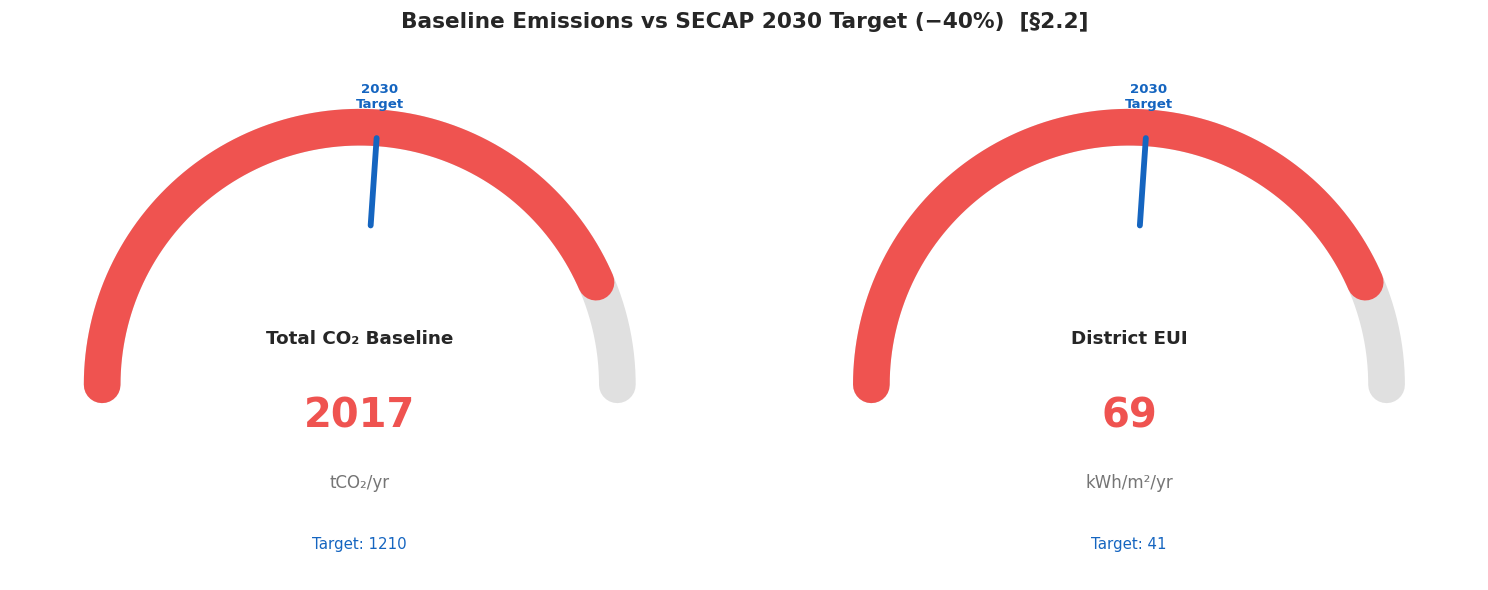

Baseline CO₂ : 2,017.3 tCO₂/yr  →  2030 target : 1,210.4 tCO₂/yr
Baseline EUI : 69.1 kWh/m²/yr  →  2030 target : 41.5 kWh/m²/yr


In [39]:
def draw_gauge(ax, value, vmax, target, title, unit, fmt='{:.0f}'):
    """Semi-circular gauge: green if value <= target, red if above."""
    theta_start, theta_end = np.pi, 0.0
    theta = np.linspace(theta_start, theta_end, 300)

    # Background arc
    ax.plot(np.cos(theta), np.sin(theta), color='#E0E0E0', linewidth=22,
            solid_capstyle='round', zorder=1)

    # Value arc
    frac = min(value / vmax, 1.0)
    theta_v = theta_start + (theta_end - theta_start) * frac
    color = '#4CAF50' if value <= target else '#EF5350'
    ax.plot(np.cos(np.linspace(theta_start, theta_v, 300)),
            np.sin(np.linspace(theta_start, theta_v, 300)),
            color=color, linewidth=22, solid_capstyle='round', zorder=2)

    # Target marker
    frac_t = min(target / vmax, 1.0)
    theta_t = theta_start + (theta_end - theta_start) * frac_t
    ax.plot([0.62 * np.cos(theta_t), 0.96 * np.cos(theta_t)],
            [0.62 * np.sin(theta_t), 0.96 * np.sin(theta_t)],
            color='#1565C0', linewidth=3.5, zorder=4)
    ax.text(1.12 * np.cos(theta_t), 1.12 * np.sin(theta_t),
            '2030\nTarget', ha='center', va='center',
            fontsize=8, color='#1565C0', fontweight='bold')

    # Labels
    ax.text(0, -0.12, fmt.format(value), ha='center', va='center',
            fontsize=24, fontweight='bold', color=color)
    ax.text(0, -0.38, unit, ha='center', va='center', fontsize=10, color='#757575')
    ax.text(0,  0.18, title, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(0, -0.62, f'Target: {fmt.format(target)}',
            ha='center', va='center', fontsize=9, color='#1565C0')

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-0.75, 1.25)
    ax.axis('off')
    ax.set_aspect('equal')


target_co2 = total_co2 * 0.60   # −40% = target ≤ 60% of baseline
eui_now    = total_final / total_gfa * 1000 if total_gfa > 0 else 0
eui_target = eui_now * 0.60

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline Emissions vs SECAP 2030 Target (−40%)  [§2.2]',
             fontsize=13, fontweight='bold')

draw_gauge(ax1, total_co2, total_co2 * 1.15, target_co2,
           'Total CO₂ Baseline', 'tCO₂/yr')
draw_gauge(ax2, eui_now, eui_now * 1.15, eui_target,
           'District EUI', 'kWh/m²/yr', fmt='{:.0f}')

plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/0B_target_gauge.png", bbox_inches='tight')
plt.show()
print(f"Baseline CO₂ : {total_co2:,.1f} tCO₂/yr  →  2030 target : {target_co2:,.1f} tCO₂/yr")
print(f"Baseline EUI : {eui_now:,.1f} kWh/m²/yr  →  2030 target : {eui_target:,.1f} kWh/m²/yr")

## Chart C — Building Sector Mix  *(§3 BEI by sector)*

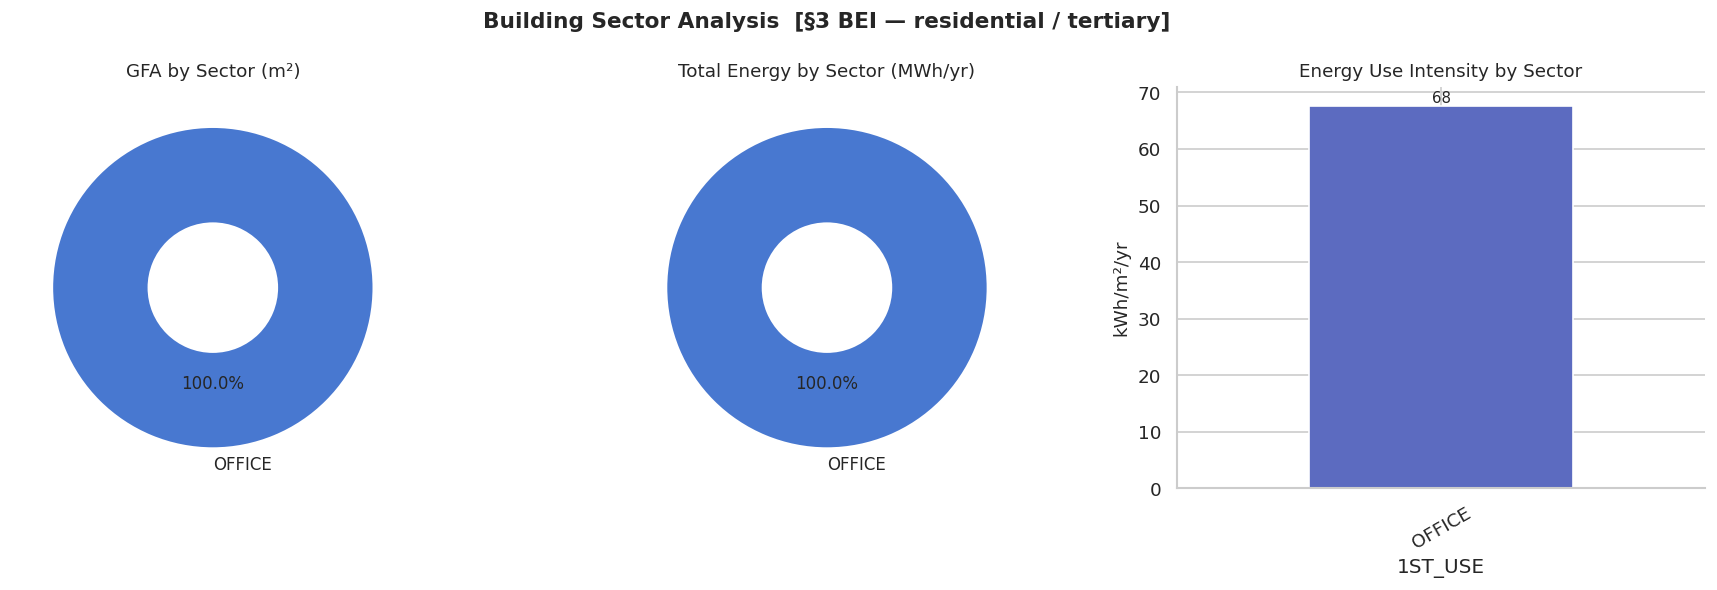

          GFA_m2  Total_MWh  EUI_kWh_m2
1ST_USE                                
OFFICE   99496.1     6726.4        67.6


In [40]:
if '1ST_USE' in df.columns and df['1ST_USE'].notna().any():
    sector_cols = ['GFA_m2', 'QH_sys_MWhyr', 'QC_sys_MWhyr', 'GRID_MWhyr']
    by_sector = df.groupby('1ST_USE')[sector_cols].sum()
    by_sector['Total_MWh'] = by_sector[['QH_sys_MWhyr', 'QC_sys_MWhyr', 'GRID_MWhyr']].sum(axis=1)
    by_sector['EUI_kWh_m2'] = by_sector['Total_MWh'] * 1000 / by_sector['GFA_m2']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Building Sector Analysis  [§3 BEI — residential / tertiary]',
                 fontsize=13, fontweight='bold')

    kw_pie = dict(autopct='%1.1f%%', startangle=90,
                  wedgeprops=dict(width=0.6, edgecolor='white', linewidth=1.2),
                  textprops={'fontsize': 10})

    axes[0].pie(by_sector['GFA_m2'], labels=by_sector.index, **kw_pie)
    axes[0].set_title('GFA by Sector (m²)', fontsize=11)

    axes[1].pie(by_sector['Total_MWh'], labels=by_sector.index, **kw_pie)
    axes[1].set_title('Total Energy by Sector (MWh/yr)', fontsize=11)

    by_sector['EUI_kWh_m2'].plot.bar(ax=axes[2], color='#5C6BC0', edgecolor='white')
    axes[2].set_ylabel('kWh/m²/yr', fontsize=11)
    axes[2].set_title('Energy Use Intensity by Sector', fontsize=11)
    axes[2].tick_params(axis='x', rotation=30)
    for bar in axes[2].patches:
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(by_sector['EUI_kWh_m2']) * 0.01,
                     f'{bar.get_height():.0f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{CHARTS_OUT}/0C_sector_mix.png", bbox_inches='tight')
    plt.show()
    print(by_sector[['GFA_m2', 'Total_MWh', 'EUI_kWh_m2']].round(1))
else:
    print("Typology data not available — sector chart skipped.")

## Chart 2 — Load Duration Curves  *(§5 Mitigation — infrastructure sizing)*

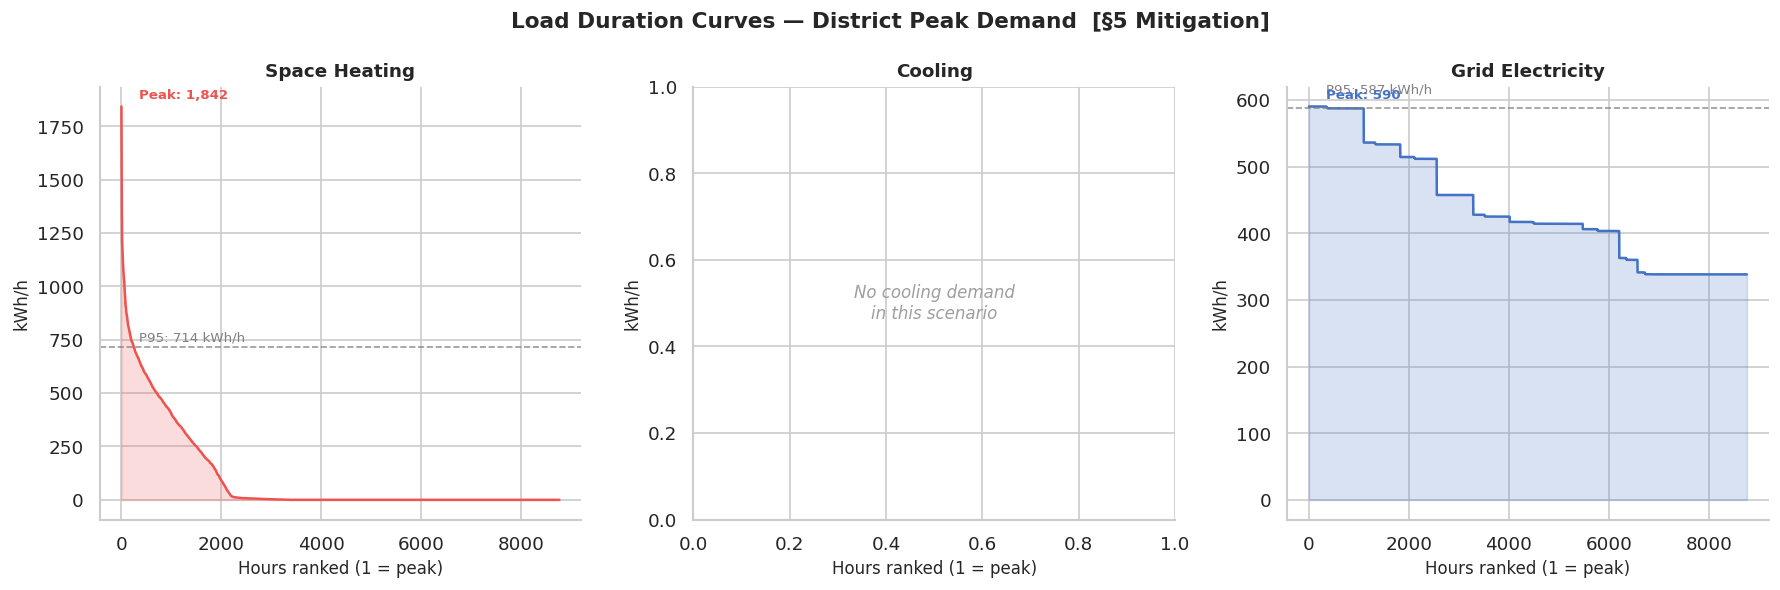

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Load Duration Curves — District Peak Demand  [§5 Mitigation]',
             fontsize=13, fontweight='bold')

ldc_specs = [
    ('Qhs_kWh',  'Space Heating', '#EF5350'),
    ('Qcs_kWh',  'Cooling',        '#29B6F6'),
    ('GRID_kWh', 'Grid Electricity','#4472C4'),
]

for ax, (col, title, color) in zip(axes, ldc_specs):
    if col not in dfh.columns:
        ax.text(0.5, 0.5, f'{col}\nnot found', transform=ax.transAxes,
                ha='center', va='center', color='grey')
        ax.set_title(title)
        continue

    vals = np.sort(dfh[col].fillna(0).values)[::-1]
    hours = np.arange(1, len(vals) + 1)

    # Skip sub-plot if demand is zero (e.g. cooling not simulated)
    if vals.max() == 0:
        ax.text(0.5, 0.5, f'No {title.lower()} demand\nin this scenario',
                transform=ax.transAxes, ha='center', va='center',
                color='#9E9E9E', fontsize=10, style='italic')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Hours ranked (1 = peak)', fontsize=10)
        ax.set_ylabel('kWh/h', fontsize=10)
        continue

    ax.fill_between(hours, vals, alpha=0.20, color=color)
    ax.plot(hours, vals, color=color, linewidth=1.5)

    # 95th percentile line (covers 95% of hours)
    p95 = np.percentile(vals[vals > 0], 95) if (vals > 0).any() else 0
    ax.axhline(p95, color='grey', linestyle='--', linewidth=1, alpha=0.8)
    ax.text(len(hours) * 0.04, p95 * 1.04, f'P95: {p95:,.0f} kWh/h',
            fontsize=8, color='grey')

    # Peak label
    ax.text(len(hours) * 0.04, vals[0] * 1.02, f'Peak: {vals[0]:,.0f}',
            fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Hours ranked (1 = peak)', fontsize=10)
    ax.set_ylabel('kWh/h', fontsize=10)

plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/02_load_duration_curves.png", bbox_inches='tight')
plt.show()


## Chart 3 — Monthly Demand Profile  *(§4 RVA seasonal)*

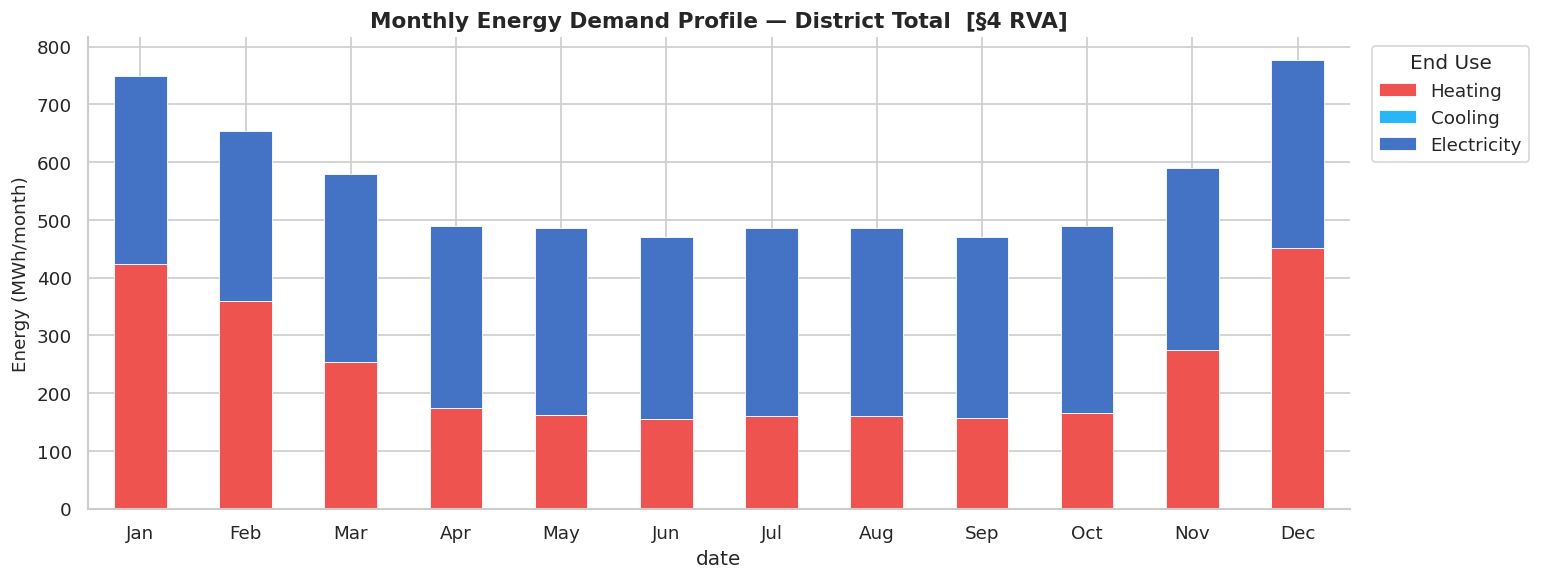

In [42]:
heat_col = 'QH_sys_kWh' if 'QH_sys_kWh' in dfh.columns else 'Qhs_kWh'
cool_col = 'QC_sys_kWh' if 'QC_sys_kWh' in dfh.columns else 'Qcs_kWh'

monthly = (
    dfh[[heat_col, cool_col, 'GRID_kWh']]
    .resample('ME').sum() / 1e3  # → MWh/month
)
monthly.columns = ['Heating', 'Cooling', 'Electricity']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 5))
monthly.plot.bar(stacked=True, ax=ax,
                 color=['#EF5350', '#29B6F6', '#4472C4'],
                 edgecolor='white', linewidth=0.5)
ax.set_title('Monthly Energy Demand Profile — District Total  [§4 RVA]',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Energy (MWh/month)', fontsize=11)
ax.set_xticklabels(month_labels, rotation=0)
ax.legend(title='End Use', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/03_monthly_demand.png", bbox_inches='tight')
plt.show()

## Chart 4 — Heat Stress Risk Heatmap  *(§4 RVA — heatwave vulnerability + §6 Adaptation)*


ℹ  Cooling column 'QC_sys_kWh' exists but is all zeros — cooling heatmap skipped.
   Run CEA cooling simulation to populate cooling demand data.


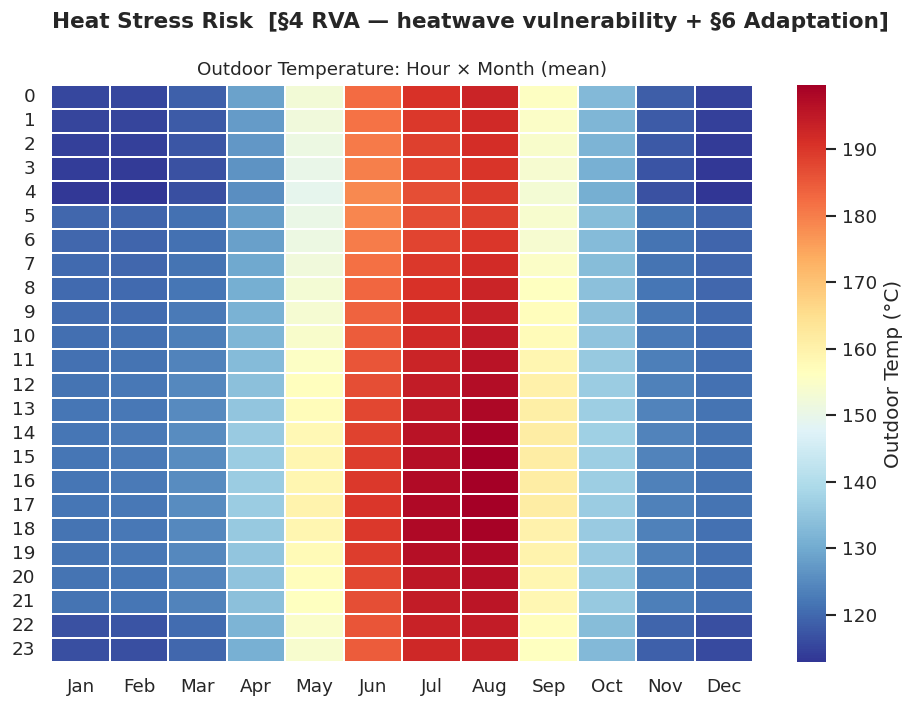

In [43]:
dfh_h = dfh.copy()
dfh_h['month'] = dfh_h.index.month
dfh_h['hour']  = dfh_h.index.hour

cooling_candidate = next((c for c in ['QC_sys_kWh', 'Qcs_kWh'] if c in dfh_h.columns), None)
# Only use cooling column if it actually has non-zero data
cool_col_h = cooling_candidate if (cooling_candidate and dfh_h[cooling_candidate].sum() > 0) else None
has_tout   = 'theta_o_C' in dfh_h.columns
month_labels_short = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

n_panels = (1 if cool_col_h else 0) + (1 if has_tout else 0)
if n_panels == 0:
    print("No cooling demand or outdoor-temperature column — skipping chart.")
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]
    fig.suptitle('Heat Stress Risk  [§4 RVA — heatwave vulnerability + §6 Adaptation]',
                 fontsize=13, fontweight='bold')
    panel = 0

    if cool_col_h:
        pivot_cool = dfh_h.pivot_table(
            values=cool_col_h, index='hour', columns='month', aggfunc='mean'
        )
        pivot_cool.columns = month_labels_short
        sns.heatmap(pivot_cool, ax=axes[panel], cmap='YlOrRd', linewidths=0.05,
                    cbar_kws={'label': 'Mean Cooling kWh/h'})
        axes[panel].set_title('Cooling Demand: Hour × Month (mean)', fontsize=11)
        axes[panel].set_ylabel('Hour of Day')
        panel += 1

    if has_tout:
        pivot_temp = dfh_h.pivot_table(
            values='theta_o_C', index='hour', columns='month', aggfunc='mean'
        )
        pivot_temp.columns = month_labels_short
        sns.heatmap(pivot_temp, ax=axes[panel], cmap='RdYlBu_r', linewidths=0.05,
                    cbar_kws={'label': 'Outdoor Temp (°C)'})
        axes[panel].set_title('Outdoor Temperature: Hour × Month (mean)', fontsize=11)
        axes[panel].set_ylabel('')

    if cool_col_h is None and cooling_candidate:
        print(f"ℹ  Cooling column '{cooling_candidate}' exists but is all zeros — cooling heatmap skipped.")
        print("   Run CEA cooling simulation to populate cooling demand data.")

    plt.tight_layout()
    plt.savefig(f"{CHARTS_OUT}/04_heat_stress_heatmap.png", bbox_inches='tight')
    plt.show()


## Chart 5 — EUI Distribution & Outlier Flagging  *(§3 BEI + §5 targeting)*

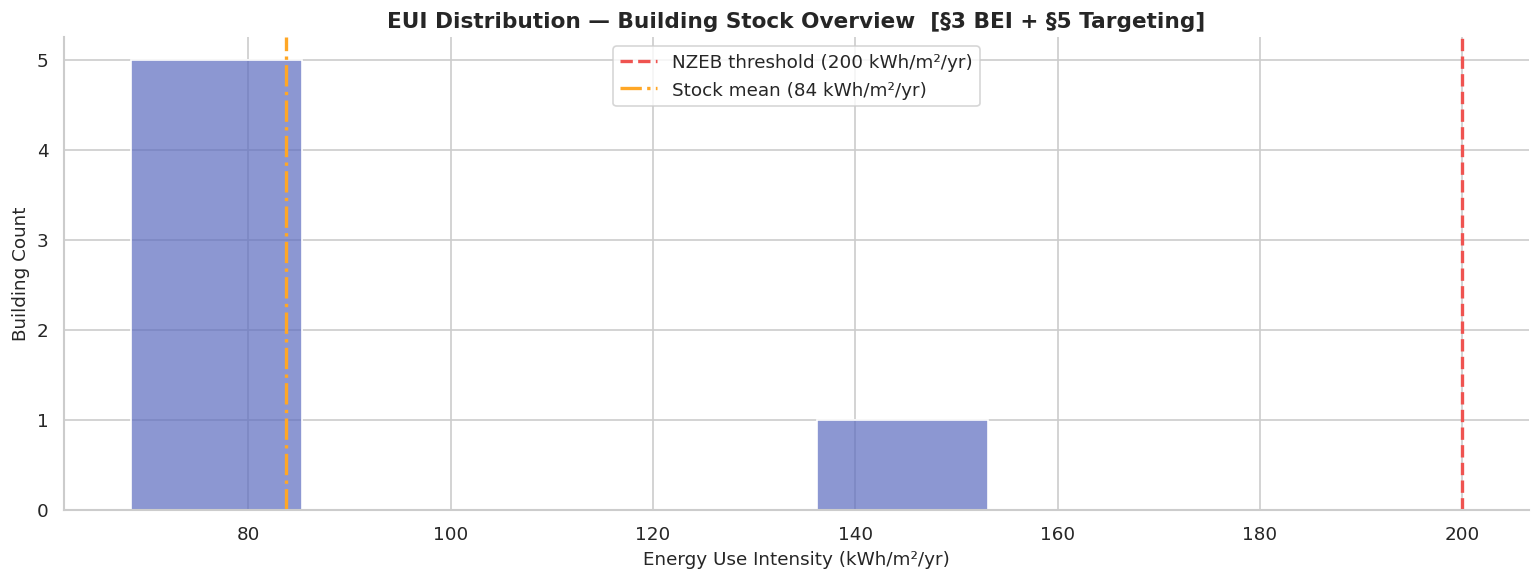


Buildings: 6  |  Bins used: 5
Outliers above 200 kWh/m²/yr: 0 / 6 buildings
All buildings below NZEB threshold — no priority outliers.


In [44]:
# NZEB threshold — adjust if needed
THRESHOLD_EUI = 200  # kWh/m²/yr

df_eui = df.copy()
df_eui['total_final_MWh'] = (
    df['GRID_MWhyr']
    + df[['NG_hs_MWhyr', 'NG_ww_MWhyr', 'COAL_hs_MWhyr', 'COAL_ww_MWhyr',
          'OIL_hs_MWhyr', 'OIL_ww_MWhyr', 'WOOD_hs_MWhyr', 'WOOD_ww_MWhyr',
          'DH_hs_MWhyr', 'DH_ww_MWhyr', 'SOLAR_hs_MWhyr', 'SOLAR_ww_MWhyr']]
         .sum(axis=1)
)
df_eui['EUI_kWh_m2'] = df_eui['total_final_MWh'] * 1000 / df_eui['GFA_m2']

outliers = df_eui[df_eui['EUI_kWh_m2'] > THRESHOLD_EUI]
mean_eui  = df_eui['EUI_kWh_m2'].mean()

# Bin count: use Sturges' rule for small N, cap at 30 for large N
n_bldg = len(df_eui)
n_bins = max(5, min(int(np.ceil(np.log2(n_bldg) + 1)), 30))

fig, ax = plt.subplots(figsize=(13, 5))
sns.histplot(df_eui['EUI_kWh_m2'], ax=ax, bins=n_bins,
             kde=n_bldg >= 10, color='#5C6BC0', alpha=0.7)
ax.axvline(THRESHOLD_EUI, color='#EF5350', linewidth=2, linestyle='--',
           label=f'NZEB threshold ({THRESHOLD_EUI} kWh/m²/yr)')
ax.axvline(mean_eui, color='#FFA726', linewidth=2, linestyle='-.',
           label=f'Stock mean ({mean_eui:.0f} kWh/m²/yr)')

# Annotate outliers above threshold
y_max = ax.get_ylim()[1]
for bname, row in outliers.iterrows():
    ax.annotate(
        f'{bname}\n({row["EUI_kWh_m2"]:.0f})',
        xy=(row['EUI_kWh_m2'], 0.05 * y_max),
        xytext=(row['EUI_kWh_m2'], 0.45 * y_max),
        arrowprops=dict(arrowstyle='->', color='#EF5350', lw=1.3),
        fontsize=8, color='#EF5350', ha='center',
    )

ax.set_xlabel('Energy Use Intensity (kWh/m²/yr)', fontsize=11)
ax.set_ylabel('Building Count', fontsize=11)
ax.set_title('EUI Distribution — Building Stock Overview  [§3 BEI + §5 Targeting]',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/05_eui_distribution.png", bbox_inches='tight')
plt.show()

print(f"\nBuildings: {n_bldg}  |  Bins used: {n_bins}")
print(f"Outliers above {THRESHOLD_EUI} kWh/m²/yr: {len(outliers)} / {n_bldg} buildings")
if len(outliers):
    cols = ['GFA_m2', 'EUI_kWh_m2'] + (['1ST_USE'] if '1ST_USE' in outliers else [])
    print(outliers[cols].sort_values('EUI_kWh_m2', ascending=False).round(1).to_string())
else:
    print("All buildings below NZEB threshold — no priority outliers.")


## Chart 6 — Solar PV Potential vs Total Demand  *(§5 Mitigation — solar)*

In [45]:
df_solar = df_eui[['GFA_m2', 'Aroof_m2', 'total_final_MWh', 'PV_MWhyr']].copy()

# Guard: PV not simulated
if df_solar['PV_MWhyr'].sum() == 0:
    print("⚠  PV_MWhyr = 0 for all buildings.")
    print("   The CEA photovoltaic analysis has not been run for this scenario.")
    print("   Run: cea photovoltaic  (or enable it in the CEA workflow)")
    print("   Chart 6 cannot be generated until PV data is available.")
else:
    df_solar['gap_MWh']      = df_solar['total_final_MWh'] - df_solar['PV_MWhyr']
    df_solar['coverage_pct'] = (df_solar['PV_MWhyr'] / df_solar['total_final_MWh'] * 100).clip(0, 100)
    df_solar = df_solar.sort_values('gap_MWh', ascending=False)

    x   = np.arange(len(df_solar))
    w   = 0.38
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w/2, df_solar['total_final_MWh'], w,
           label='Total Demand (MWh/yr)', color='#EF5350', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, df_solar['PV_MWhyr'], w,
           label='PV Generation Potential (MWh/yr)', color='#FDD835', alpha=0.90, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(df_solar.index, rotation=30, ha='right')
    ax.set_ylabel('MWh/yr', fontsize=11)
    ax.set_title('Solar PV Potential vs Total Demand  [§5 Mitigation — solar action]',
                 fontsize=13, fontweight='bold')
    ax.legend()

    for xi, (_, row) in zip(x, df_solar.iterrows()):
        top = max(row['total_final_MWh'], row['PV_MWhyr'])
        ax.text(xi, top * 1.03, f"{row['coverage_pct']:.0f}%",
                ha='center', fontsize=9, color='#5C6BC0', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{CHARTS_OUT}/06_solar_vs_demand.png", bbox_inches='tight')
    plt.show()
    print(df_solar[['total_final_MWh', 'PV_MWhyr', 'coverage_pct', 'gap_MWh']].round(1).to_string())


⚠  PV_MWhyr = 0 for all buildings.
   The CEA photovoltaic analysis has not been run for this scenario.
   Run: cea photovoltaic  (or enable it in the CEA workflow)
   Chart 6 cannot be generated until PV data is available.


## Chart 7 — District Energy Loop Opportunity  *(§5 Mitigation — heat exchange)*

In [46]:
heat_col_l = 'Qhs_kWh'
cool_col_l = next((c for c in ['QC_sys_kWh', 'Qcs_kWh'] if c in dfh.columns), None)

if cool_col_l is None or heat_col_l not in dfh.columns:
    print("Required columns not found — skipping District Loop chart.")
elif dfh[cool_col_l].sum() == 0:
    print("⚠  Cooling demand is zero — district loop analysis not applicable.")
    print("   Run CEA cooling simulation to enable this chart.")
else:
    loop = dfh[[heat_col_l, cool_col_l]].copy()
    loop.columns = ['Heating_kWh', 'Cooling_kWh']
    loop = loop.fillna(0)

    mask_both  = (loop['Heating_kWh'] > 0) & (loop['Cooling_kWh'] > 0)
    mask_honly = (loop['Heating_kWh'] > 0) & (loop['Cooling_kWh'] == 0)
    mask_conly = (loop['Heating_kWh'] == 0) & (loop['Cooling_kWh'] > 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('District Energy Loop Opportunity  [§5 Mitigation — heat exchange loop]',
                 fontsize=13, fontweight='bold')

    ax1.scatter(loop.loc[mask_honly, 'Heating_kWh'], loop.loc[mask_honly, 'Cooling_kWh'],
                alpha=0.12, s=4, color='#EF5350',
                label=f'Heating only ({mask_honly.sum():,} h)')
    ax1.scatter(loop.loc[mask_conly, 'Heating_kWh'], loop.loc[mask_conly, 'Cooling_kWh'],
                alpha=0.12, s=4, color='#29B6F6',
                label=f'Cooling only ({mask_conly.sum():,} h)')
    ax1.scatter(loop.loc[mask_both, 'Heating_kWh'], loop.loc[mask_both, 'Cooling_kWh'],
                alpha=0.50, s=10, color='#7B1FA2',
                label=f'Simultaneous ★ ({mask_both.sum():,} h)')
    ax1.set_xlabel('District Heating Load (kWh/h)', fontsize=10)
    ax1.set_ylabel('District Cooling Load (kWh/h)', fontsize=10)
    ax1.set_title('Hourly Load Scatter', fontsize=11)
    ax1.legend(fontsize=8)

    opp_heat = loop.loc[mask_both, 'Heating_kWh'].sum() / 1000
    opp_cool = loop.loc[mask_both, 'Cooling_kWh'].sum() / 1000
    ax2.bar(['Recoverable\nHeat (MWh/yr)', 'Offset Cooling\n(MWh/yr)'],
            [opp_heat, opp_cool],
            color=['#EF5350', '#29B6F6'], edgecolor='white', width=0.5)
    ax2.set_ylabel('MWh/yr', fontsize=11)
    ax2.set_title('Waste Heat Recovery Potential', fontsize=11)
    for bar in ax2.patches:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'{bar.get_height():,.1f}', ha='center', fontsize=10, fontweight='bold')

    print(f"Simultaneous hours : {mask_both.sum():,} h  ({mask_both.mean()*100:.1f}% of year)")
    print(f"Recoverable heat   : {opp_heat:,.1f} MWh/yr")
    print(f"Offset cooling     : {opp_cool:,.1f} MWh/yr")

    plt.tight_layout()
    plt.savefig(f"{CHARTS_OUT}/07_district_loop_opportunity.png", bbox_inches='tight')
    plt.show()


⚠  Cooling demand is zero — district loop analysis not applicable.
   Run CEA cooling simulation to enable this chart.


## Chart 8 — CO₂ Reduction Pathway (Waterfall)  *(§5 Mitigation — GHG per action)*

ℹ  PV_MWhyr = 0 — Solar PV scenario excluded from waterfall (run CEA photovoltaic first).


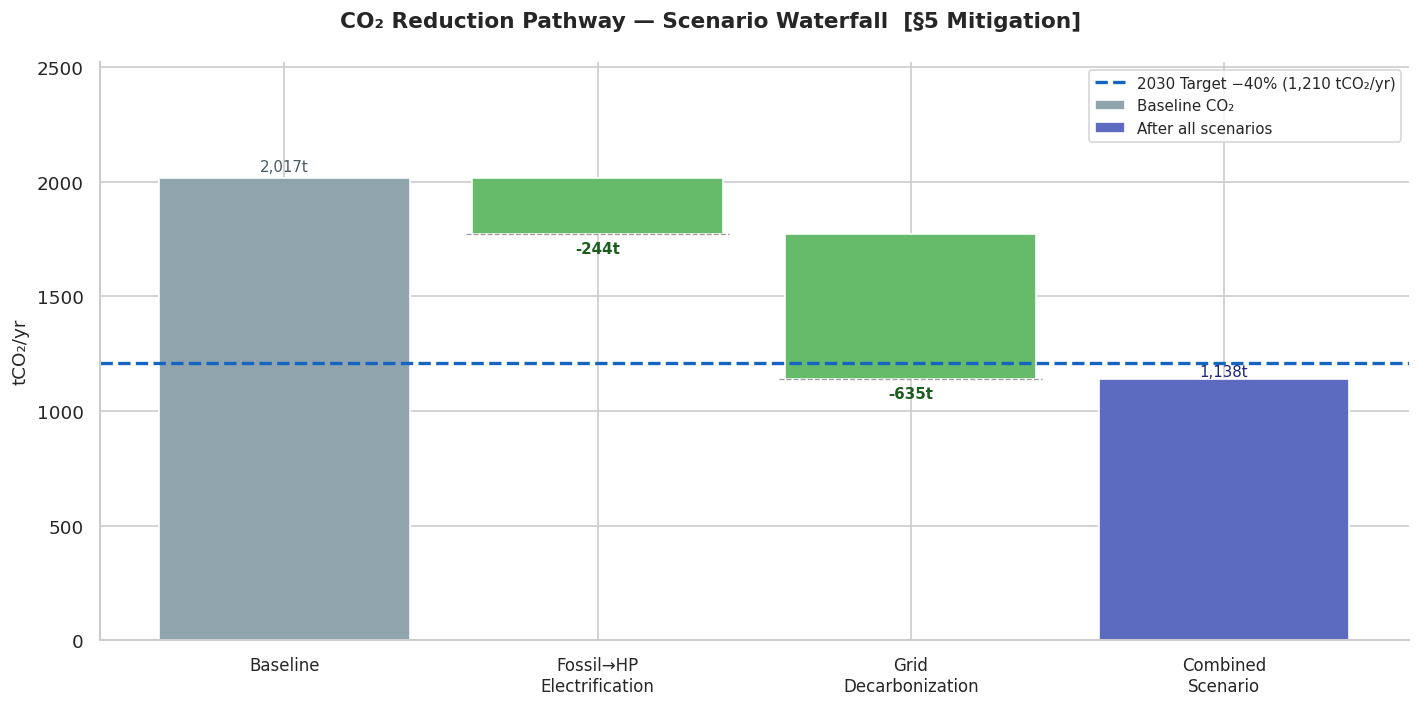


Baseline       : 2,017.3 tCO₂/yr
After scenarios: 1,137.8 tCO₂/yr  (+43.6%)
2030 Target    : 1,210.4 tCO₂/yr  (−40%)
Gap to target  : -72.6 tCO₂/yr


In [47]:
# Scenario definitions
COP = 3.0          # heat pump COP assumed
GRID_2030_EF = 0.200  # DE grid 2030 target tCO₂/MWh (= 0.200 kgCO₂/kWh)

ng_mwh   = (df['NG_hs_MWhyr']   + df['NG_ww_MWhyr']).sum()
oil_mwh  = (df['OIL_hs_MWhyr']  + df['OIL_ww_MWhyr']).sum()
coal_mwh = (df['COAL_hs_MWhyr'] + df['COAL_ww_MWhyr']).sum()
grid_mwh = df['GRID_MWhyr'].sum()
pv_mwh   = df['PV_MWhyr'].sum()

co2_fossil = ng_mwh * EF['NG'] + oil_mwh * EF['OIL'] + coal_mwh * EF['COAL']

# Build scenario list dynamically — skip scenarios with zero effect
scenarios = []
if co2_fossil > 0:
    s1 = -(co2_fossil) + (ng_mwh + oil_mwh + coal_mwh) / COP * EF['GRID']
    scenarios.append(('Fossil→HP\nElectrification', s1))

s2 = grid_mwh * (GRID_2030_EF - EF['GRID'])
scenarios.append(('Grid\nDecarbonization', s2))

if pv_mwh > 0:
    s3 = -pv_mwh * EF['GRID']
    scenarios.append(('Rooftop\nSolar PV', s3))
else:
    print("ℹ  PV_MWhyr = 0 — Solar PV scenario excluded from waterfall (run CEA photovoltaic first).")

cumulative = [total_co2]
for _, d in scenarios:
    cumulative.append(cumulative[-1] + d)

x_labels = ['Baseline'] + [lbl for lbl, _ in scenarios] + ['Combined\nScenario']

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('CO₂ Reduction Pathway — Scenario Waterfall  [§5 Mitigation]',
             fontsize=13, fontweight='bold')

ax.bar(0, total_co2, color='#90A4AE', edgecolor='white', label='Baseline CO₂')
ax.text(0, total_co2 * 1.015, f'{total_co2:,.0f}t', ha='center', fontsize=9, color='#455A64')

for i, (lbl, d) in enumerate(scenarios, start=1):
    bottom  = cumulative[i - 1] + min(d, 0)
    bar_h   = abs(d)
    bar_col = '#EF5350' if d > 0 else '#66BB6A'
    ax.bar(i, bar_h, bottom=bottom, color=bar_col, edgecolor='white')
    label_y = cumulative[i] + (total_co2 * 0.015 if d > 0 else -total_co2 * 0.015)
    va_pos  = 'bottom' if d > 0 else 'top'
    ax.text(i, label_y, f'{d:+,.0f}t', ha='center', fontsize=9,
            fontweight='bold', va=va_pos, color='#1B5E20' if d < 0 else '#B71C1C')
    ax.plot([i - 0.42, i + 0.42], [cumulative[i], cumulative[i]],
            color='#9E9E9E', lw=0.8, linestyle='--')

final_x = len(scenarios) + 1
ax.bar(final_x, cumulative[-1], color='#5C6BC0', edgecolor='white', label='After all scenarios')
ax.text(final_x, cumulative[-1] * 1.015, f'{cumulative[-1]:,.0f}t',
        ha='center', fontsize=9, color='#1A237E')

target_line = total_co2 * 0.60
ax.axhline(target_line, color='#1565C0', linestyle='--', linewidth=2,
           label=f'2030 Target −40% ({target_line:,.0f} tCO₂/yr)')

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel('tCO₂/yr', fontsize=11)
ax.set_ylim(0, total_co2 * 1.25)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_OUT}/08_co2_waterfall.png", bbox_inches='tight')
plt.show()

reduction_pct = (1 - cumulative[-1] / total_co2) * 100
print(f"\nBaseline       : {total_co2:,.1f} tCO₂/yr")
print(f"After scenarios: {cumulative[-1]:,.1f} tCO₂/yr  ({reduction_pct:+.1f}%)")
print(f"2030 Target    : {target_line:,.1f} tCO₂/yr  (−40%)")
print(f"Gap to target  : {cumulative[-1] - target_line:,.1f} tCO₂/yr")


## Chart D — Fossil Fuel Phase-Out Timeline  *(§5 Mitigation — timing + §2.7 monitoring)*

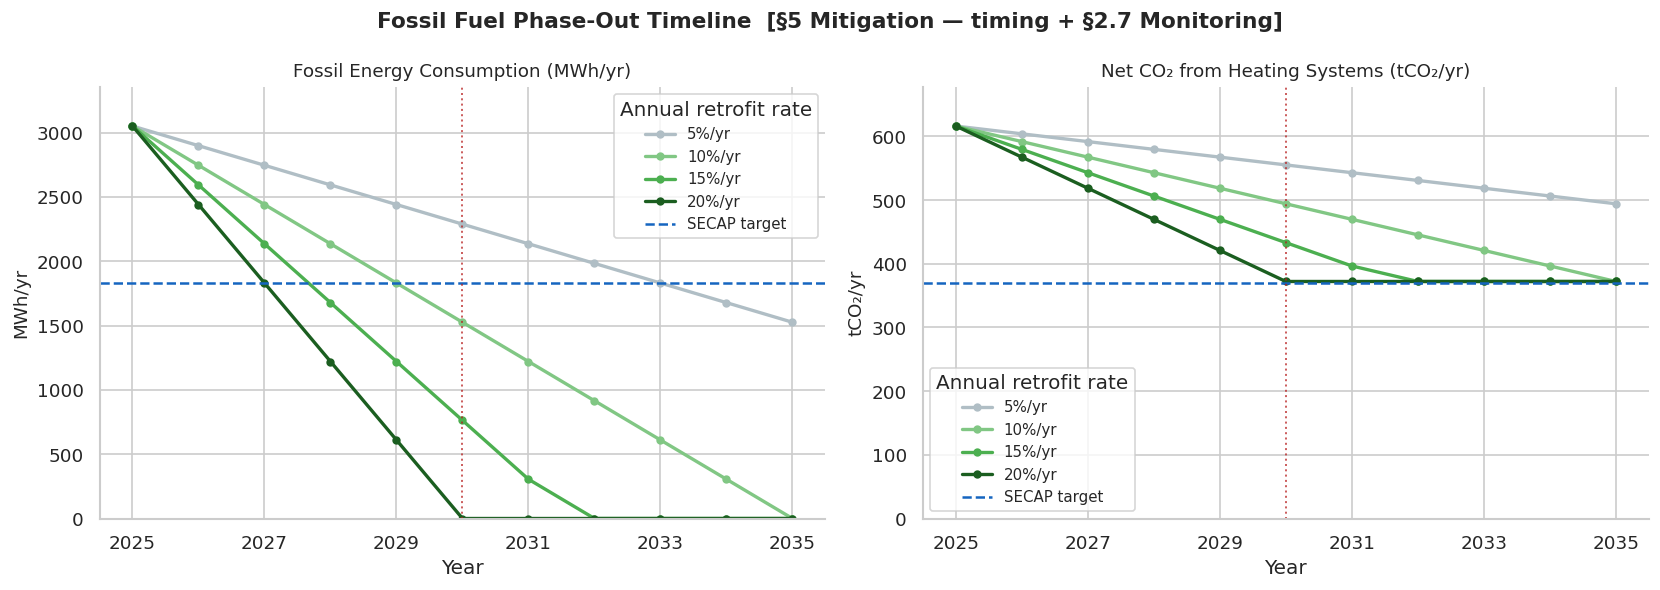


Retrofit rate needed to meet −40% by 2030 from fossil heating:
   5%/yr  →  25% reduction by 2030  ✗
  10%/yr  →  50% reduction by 2030  ✓
  15%/yr  →  75% reduction by 2030  ✓
  20%/yr  →  100% reduction by 2030  ✓


In [48]:
years = np.arange(2025, 2036)
baseline_fossil_co2 = co2_fossil  # from Chart 8 computation
reduction_target_pct = 40

if fossil_mwh == 0:
    print("⚠  No fossil fuel consumption in this scenario — phase-out timeline not applicable.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Fossil Fuel Phase-Out Timeline  [§5 Mitigation — timing + §2.7 Monitoring]',
                 fontsize=13, fontweight='bold')

    colors_rate = ['#B0BEC5', '#81C784', '#4CAF50', '#1B5E20']

    for rate_pct, color in zip([5, 10, 15, 20], colors_rate):
        remaining_fraction = [1.0]
        for y in years[1:]:
            remaining_fraction.append(max(remaining_fraction[-1] - rate_pct / 100, 0))
        remaining_fraction = np.array(remaining_fraction)

        fossil_mwh_yr  = fossil_mwh * remaining_fraction
        fossil_co2_yr  = baseline_fossil_co2 * remaining_fraction
        replaced_mwh   = fossil_mwh * (1 - remaining_fraction)
        hp_extra_co2   = replaced_mwh / COP * EF['GRID']
        net_fossil_co2 = fossil_co2_yr + hp_extra_co2

        lbl = f'{rate_pct}%/yr'
        ax1.plot(years, fossil_mwh_yr,  color=color, linewidth=2, marker='o', markersize=4, label=lbl)
        ax2.plot(years, net_fossil_co2, color=color, linewidth=2, marker='o', markersize=4, label=lbl)

    # 2030 target lines
    ax1.axhline(fossil_mwh * (1 - reduction_target_pct/100), color='#1565C0',
                linestyle='--', linewidth=1.5, label='SECAP target')
    ax2.axhline(baseline_fossil_co2 * (1 - reduction_target_pct/100), color='#1565C0',
                linestyle='--', linewidth=1.5, label='SECAP target')
    ax2.axvline(2030, color='#B71C1C', linestyle=':', linewidth=1.2, alpha=0.7)
    ax1.axvline(2030, color='#B71C1C', linestyle=':', linewidth=1.2, alpha=0.7)

    # Force y-axis from 0 so visual slope is not exaggerated
    ax1.set_ylim(0, fossil_mwh * 1.10)
    ax2.set_ylim(0, baseline_fossil_co2 * 1.10)

    ax1.set_title('Fossil Energy Consumption (MWh/yr)', fontsize=11)
    ax1.set_ylabel('MWh/yr', fontsize=11)
    ax1.set_xlabel('Year')
    ax1.legend(title='Annual retrofit rate', fontsize=9)
    ax1.set_xticks(years[::2])

    ax2.set_title('Net CO₂ from Heating Systems (tCO₂/yr)', fontsize=11)
    ax2.set_ylabel('tCO₂/yr', fontsize=11)
    ax2.set_xlabel('Year')
    ax2.legend(title='Annual retrofit rate', fontsize=9)
    ax2.set_xticks(years[::2])

    plt.tight_layout()
    plt.savefig(f"{CHARTS_OUT}/0D_fossil_phase_out_timeline.png", bbox_inches='tight')
    plt.show()

    print("\nRetrofit rate needed to meet −40% by 2030 from fossil heating:")
    for rate in [5, 10, 15, 20]:
        fraction_2030 = max(1.0 - rate / 100 * (2030 - 2025), 0)
        reduction_2030 = (1 - fraction_2030) * 100
        meets = '✓' if reduction_2030 >= reduction_target_pct else '✗'
        print(f"  {rate:2d}%/yr  →  {reduction_2030:.0f}% reduction by 2030  {meets}")


---
## Summary

All charts saved to `{SCENARIO_DIR}/outputs/charts/`.

| File | Chart | SECAP |
|------|-------|-------|
| `01_energy_mix.png` | Energy mix + CO₂ | §3 BEI |
| `0A_end_use_breakdown.png` | End-use donut | §3 BEI |
| `0B_target_gauge.png` | Emissions gauge | §2.2 |
| `0C_sector_mix.png` | Sector mix | §3 BEI |
| `02_load_duration_curves.png` | LDCs | §5 |
| `03_monthly_demand.png` | Monthly profile | §4 RVA |
| `04_heat_stress_heatmap.png` | Heat stress | §4 RVA + §6 Adaptation |
| `05_eui_distribution.png` | EUI + outliers | §3 + §5 |
| `06_solar_vs_demand.png` | Solar potential | §5 |
| `07_district_loop_opportunity.png` | Heat loop | §5 |
| `08_co2_waterfall.png` | CO₂ waterfall | §5 |
| `0D_fossil_phase_out_timeline.png` | Phase-out timeline | §5 + §2.7 |

> **Scope:** These charts cover the **built environment only** — buildings energy demand, solar potential, and associated emissions. This is the intended scope of this project (no transport, waste, or other sectors).
